In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
#import torch
#import torch.nn as nn
#from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics.pairwise import cosine_similarity
from invariances import build_standardscaled_distance_graph, build_dtw_graph, build_cid_graph
import networkx as nx
import matplotlib.pyplot as plt
from plot import save_graph_plot


In [2]:
DATA_PATH = '../../dataset/representative_items.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df = pd.read_feather(DATA_PATH)

# Filter X number of items for testing
NUM_ITEMS = 100
df = df[df['item_id'].isin(df['item_id'].unique()[:NUM_ITEMS])]



Loading data from ../../dataset/representative_items.feather...


In [3]:
# Define constants
DATE_COL = 'date'
TARGET_COL = 'value'  # Assuming 'value' is the target variable (sales at the end of the day)


# Handle DATE_COL (ensure it is a column and not in the index)
if DATE_COL in df.index.names:
    if DATE_COL in df.columns:
        # If it's in both, drop the index version to avoid "cannot insert" error
        df = df.reset_index(drop=True)
    else:
        # If it's only in the index, move it to a column
        df = df.reset_index()

# If DATE_COL is NOT in columns (and wasn't in index), we have a problem, but assuming it exists somewhere.
# Just to be safe, if we still have a complex index, reset it.
if df.index.name == DATE_COL:
     df = df.reset_index(drop=True)
     
# Fallback: simple reset to ensure RangeIndex 0..N
df = df.reset_index(drop=True)

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df['item_id'] = df['item_id'].astype(int) # or .astype(str)
df = df.reset_index(drop=True) # Final clean reset

# Prepare target variable
# Using 'value' as the target (sales at the end of the day)
y = df[TARGET_COL]
print(len(y))

# Calandar-based features
# Ensure datetime
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Base calendar parts
df["day_of_week"]  = df[DATE_COL].dt.dayofweek.astype(int)
df["day_of_month"] = df[DATE_COL].dt.day.astype(int)         
df["moy"]          = df[DATE_COL].dt.month.astype(int)-1      
df["doy"]          = df[DATE_COL].dt.dayofyear.astype(int)-1   
df["is_weekend"] = (
    (df[DATE_COL].dt.dayofweek == 5) |
    (df[DATE_COL].dt.dayofweek == 6)
).astype(int)

m0 = df[DATE_COL].dt.month - 1
df["month_sin"] = np.sin(2*np.pi*m0 / 12)
df["month_cos"] = np.cos(2*np.pi*m0 / 12)

df["doy"] = df[DATE_COL].dt.dayofyear # 1..365/366
doy0 = df["doy"] - 1
P = 366 # safe; or use 365 if you drop leap years
df["doy_sin"] = np.sin(2*np.pi*doy0 / P)
df["doy_cos"] = np.cos(2*np.pi*doy0 / P)

promo_types= [col for col in df.columns if col.startswith("promo_type_")] # Binary columns indicating presence of specific promotion types
promo_values= [col for col in df.columns if col.startswith("promo_value_")] # Numerical columns indicating the value of specific promotion types

calendar_cols = ["day_of_week", "day_of_month", "moy", "doy", "is_weekend"]
calendar_trigonometric_cols = ["month_sin", "month_cos", "doy_sin", "doy_cos"]
categorical_cols = ["cat_label", "sdep_label", "dept_label"]

df = df.sort_values(["item_id", DATE_COL]).reset_index(drop=True)

df

76049


,date,item_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,item_label,day_of_week,day_of_month,moy,doy,is_weekend,month_sin,month_cos,doy_sin,doy_cos
0,2021-01-23,676,4,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,representative,5,23,0,23,1,0.0,1.000000,0.368763,0.929523
1,2021-01-24,676,4,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,representative,6,24,0,24,1,0.0,1.000000,0.384665,0.923056
2,2021-01-25,676,4,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,representative,0,25,0,25,0,0.0,1.000000,0.400454,0.916317
3,2021-01-26,676,0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,representative,1,26,0,26,0,0.0,1.000000,0.416125,0.909308
4,2021-01-27,676,3,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0,0.0,0,...,representative,2,27,0,27,0,0.0,1.000000,0.431673,0.902030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76044,2023-02-18,962454,3,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,representative,5,18,1,49,1,0.5,0.866025,0.733885,0.679273
76045,2023-02-19,962454,5,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,representative,6,19,1,50,1,0.5,0.866025,0.745438,0.666575
76046,2023-02-20,962454,1,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,representative,0,20,1,51,0,0.5,0.866025,0.756771,0.653680
76047,2023-02-21,962454,6,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0,0.0,0,...,representative,1,21,1,52,0,0.5,0.866025,0.767880,0.640593


# Amplitude / Offset-Invariant Graph
Amplitude and offset invariance can be achieved by Z-normalizing the time series for each product before calculating the Euclidean distance. 

$$z_i = \frac{x_i - \mu_i}{\sigma_i}$$
$$d_{ij} = \|z_i - z_j\|_2$$

Two products are related if their standardized shapes match, regardless of underlying scales.

In [4]:

G_invariant, dist_df, df_scaled = build_standardscaled_distance_graph(df, date_col=DATE_COL, item_col="item_id", target_col=TARGET_COL, k=3)
# Build missing objects from existing notebook variables
adj_list = {node: list(G_invariant.neighbors(node)) for node in G_invariant.nodes()}
print("Number of nodes in the graph:", G_invariant.number_of_nodes())
print("Number of edges in the graph:", G_invariant.number_of_edges())



Number of nodes in the DTW graph: 100
Number of edges in the DTW graph: 0
Number of nodes in the graph: 100
Number of edges in the graph: 0


Text(0.5, 1.0, 'Box Plot of Standard Scaled Euclidean Distances')

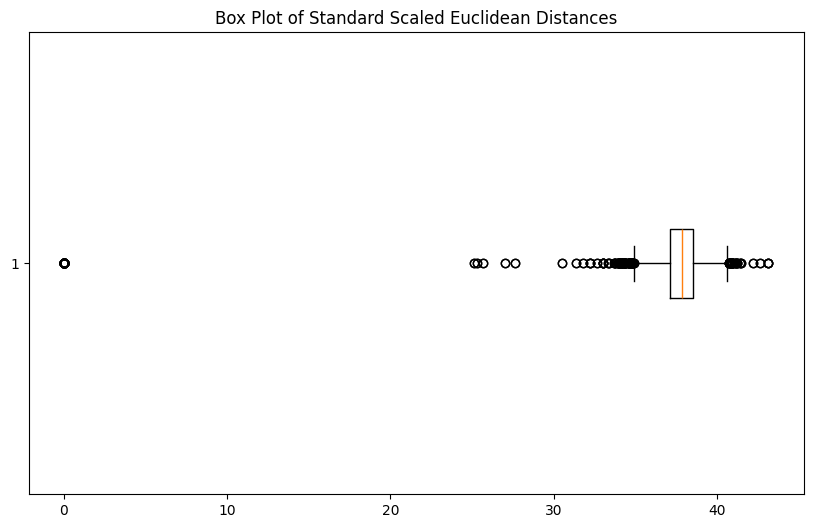

In [5]:
# Box plot of distances
plt.figure(figsize=(10, 6))
plt.boxplot(dist_df.values.flatten(), vert=False)
plt.title("Box Plot of Standard Scaled Euclidean Distances")

In [6]:
# Save the plot
save_graph_plot(G_invariant, strategy_name="Standard Scaled Euclidean", node_categories=dict(zip(df["item_id"], df["cat_label"])))

Graph automatically saved to: graph_plots\standard_scaled_euclidean_100_nodes.png


In [7]:

G_dtw, dtw_dist_df, dtw_scaled = build_dtw_graph(df, date_col=DATE_COL, item_col="item_id", target_col=TARGET_COL, distance_value_threshold=23, sakoe_chiba_radius=3)

    


Added edge between 676 and 129793 with DTW distance: 22.7725
Added edge between 676 and 582893 with DTW distance: 22.9233
Added edge between 688 and 101125 with DTW distance: 22.3924
Added edge between 691 and 604198 with DTW distance: 22.0477
Added edge between 703 and 21158 with DTW distance: 22.8315
Added edge between 809 and 101126 with DTW distance: 22.4386
Added edge between 809 and 962450 with DTW distance: 22.7177
Added edge between 20207 and 20230 with DTW distance: 20.6089
Added edge between 20207 and 21154 with DTW distance: 22.2678
Added edge between 20207 and 21160 with DTW distance: 22.4641
Added edge between 20207 and 101126 with DTW distance: 22.6804
Added edge between 20207 and 129793 with DTW distance: 22.8340
Added edge between 20207 and 288729 with DTW distance: 22.7393
Added edge between 20207 and 608215 with DTW distance: 22.7351
Added edge between 20225 and 20602 with DTW distance: 22.5161
Added edge between 20225 and 20730 with DTW distance: 21.9367
Added edge b

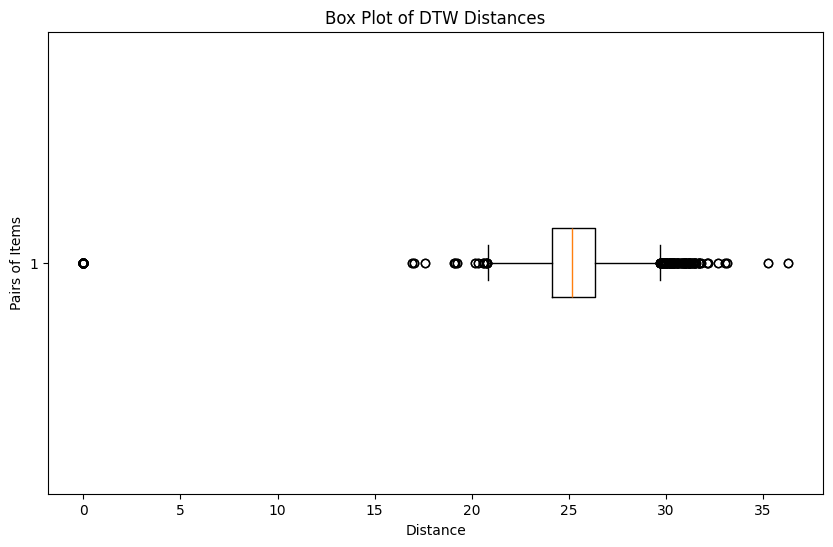

In [8]:
# Box plot of distances
plt.figure(figsize=(10, 6))
plt.boxplot(dtw_dist_df.values.flatten(), vert=False)
plt.title("Box Plot of DTW Distances")
plt.xlabel("Distance")
plt.ylabel("Pairs of Items")
plt.show()

In [9]:
# Save the plot
save_graph_plot(G_dtw, strategy_name="Dynamic Time Warping", node_categories=dict(zip(df["item_id"], df["cat_label"])))

Graph automatically saved to: graph_plots\dynamic_time_warping_100_nodes.png


In [10]:
'''
printed_pairs = set()
corr_pairs = []
print("Number of nodes in the graph:", G_invariant.number_of_nodes())
print("Number of edges in the graph:", G_invariant.number_of_edges())
for node, neighbors in adj_list.items():
    for neighbor in neighbors:
        # undirected graph -> keep unique pair
        pair = tuple(sorted((node, neighbor)))
        if pair not in printed_pairs:
            corr_val = corr_matrix.loc[node, neighbor]
            corr_pairs.append((pair[0], pair[1], corr_val))
            printed_pairs.add(pair)
# Sort by absolute correlation value and print top 20
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Top 20 pairs by absolute correlation value:")
for item1, item2, corr_val in corr_pairs[:20]:
    print(f"Item {item1} - Item {item2}: Correlation = {corr_val:.4f}")
'''

'\nprinted_pairs = set()\ncorr_pairs = []\nprint("Number of nodes in the graph:", G_invariant.number_of_nodes())\nprint("Number of edges in the graph:", G_invariant.number_of_edges())\nfor node, neighbors in adj_list.items():\n    for neighbor in neighbors:\n        # undirected graph -> keep unique pair\n        pair = tuple(sorted((node, neighbor)))\n        if pair not in printed_pairs:\n            corr_val = corr_matrix.loc[node, neighbor]\n            corr_pairs.append((pair[0], pair[1], corr_val))\n            printed_pairs.add(pair)\n# Sort by absolute correlation value and print top 20\ncorr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)\nprint("Top 20 pairs by absolute correlation value:")\nfor item1, item2, corr_val in corr_pairs[:20]:\n    print(f"Item {item1} - Item {item2}: Correlation = {corr_val:.4f}")\n'

In [ ]:
G, cid_df, df_scaled = build_cid_graph(df, date_col=DATE_COL, item_col="item_id", target_col=TARGET_COL, distance_value_threshold=10000)

Number of nodes in the CID graph: 100
Number of edges in the CID graph: 2701


Text(0.5, 1.0, 'Box Plot of CID Distances')

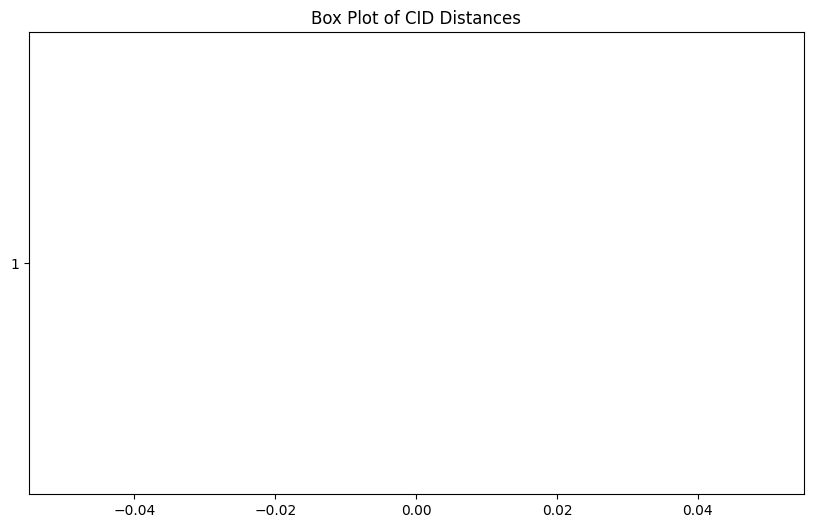

In [14]:
# Box plot of distances
plt.figure(figsize=(10, 6))
plt.boxplot(cid_df.values.flatten(), vert=False)
plt.title("Box Plot of CID Distances")

In [ ]:
# Save the plot
save_graph_plot(G_dtw, strategy_name="Complexity Invariance Distance", node_categories=dict(zip(df["item_id"], df["cat_label"])))